In [1]:
# Importing packages and data
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as ticker
from sklearn.model_selection import (cross_validate,
                            KFold,
                            train_test_split)
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import GridSearchCV
from IPython.display import display



cbb = pd.read_csv("cbb_Coaches.csv")


In [2]:
# Exploring the data
cbb1 = cbb.to_numpy()
cbb.isna().sum()

# Changing the NA's to numbers
## For postseason, we will change the postseason to 69 if they didn't make the tournament
cbb['POSTSEASON'] = cbb['POSTSEASON'].fillna(69)

## For seed, we will put 17 to show a team didn't make the tournament
cbb['SEED'] = cbb['SEED'].fillna(17)

## For last year performance, we will do the same that we did with postseason
cbb['Last_yr_performance'] = cbb['Last_yr_performance'].fillna(69)


# Now we will format postseason so it only returns numbers
cbb['POSTSEASON'] = cbb['POSTSEASON'].str.replace('[A-Za-z]', '', regex=False)

We changed these columns to numbers because we will likely write formulas that will help predict where teams will finish, and one of those criteria may be where they finished. The lower the postseason number, the better they performed.

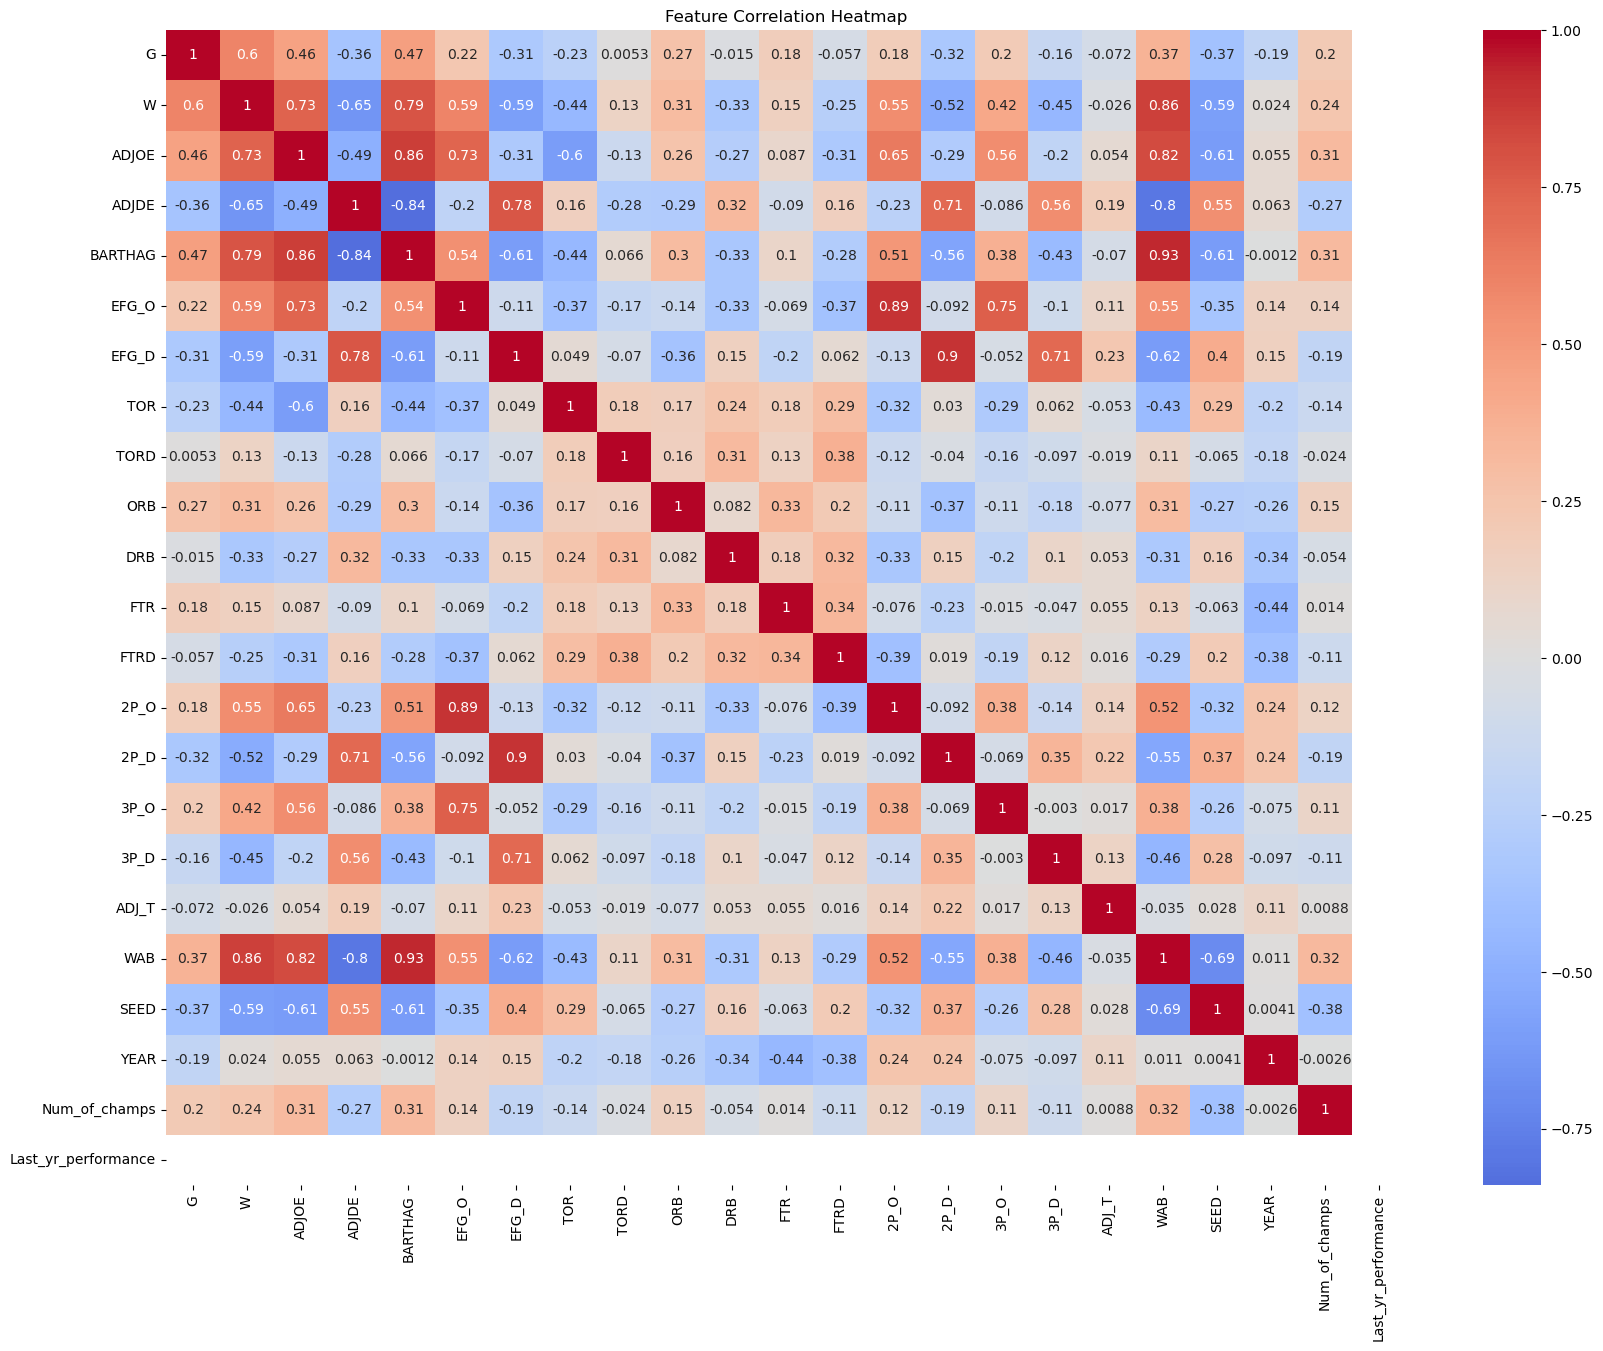

In [3]:
# Seeing how correlated each feature is to the target variable (POSTSEASON)
corr = cbb.select_dtypes(include='number').corr()

plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


What is interesting in this graph is that Adjusted Defense Efficiency(ADJDE) is almost inversely correlated with Wins Above Bubble(WAB). (How well a 'bubble' team would do against that team's schedule) A 'bubble' team is on the edge of making the national tournament. So in other words, the 69, 70, 71, 72 best teams in college basketball. This actually makes sense because the lower the number for ADJDE, the better the defense, more likely resulting in a better team. 
    Something else that is interesting is that seed is inversely correlated with Adjusted Offensive Efficiency(ADJOE). This also makes sense because the higher the ADJOE, the better your offense is, more likely resulting in a better team which leads to a lower seed. Vice versa with Adjusted Defensive Efficiency(ADJDE). The lower the number, the better the defense, more chance your team is better, the lower the seed you get. 
    One last thing, Effective Field Goal Percentage for Defense(EFG_D) correlates to 2 Point Field Goal Percentage(2P_D) very highly. This is due to the fact that EFG_D measures your opponents effective field goal percentage, which is the amount of efficient shots the team is taking in the game. The lower the EFG_D the more inefficient shots your opponent is taking. This means shots like highly contested mid-range jumpers, or floaters are being shot more which more likely results in a miss, and leads to a lower 2 point field goal percentage.

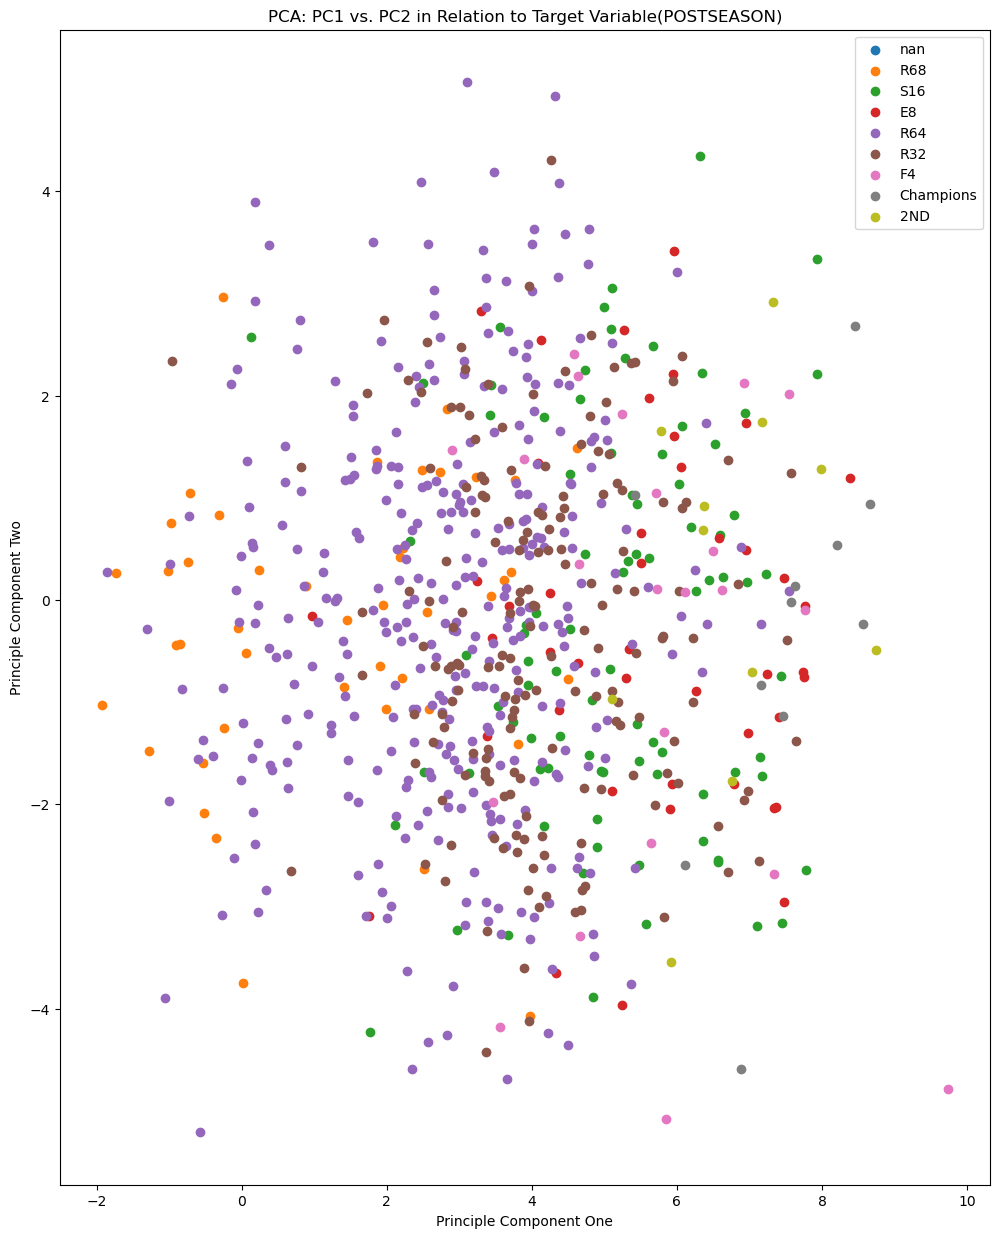

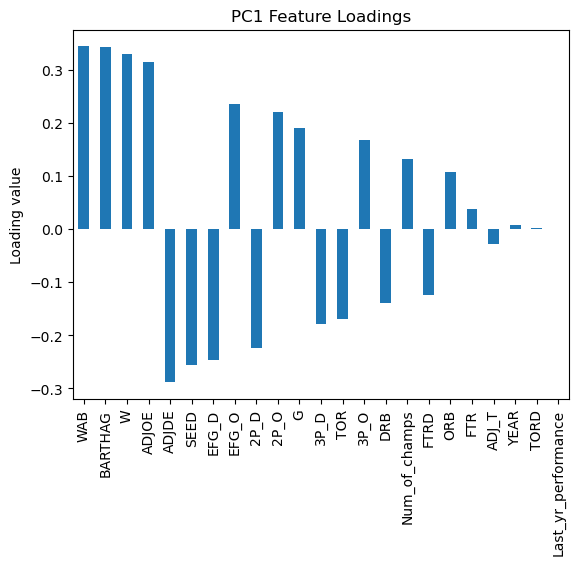

In [4]:
# Now we are going to see how correlated each feature is to the target variable (POSTSEASON)

X = cbb.drop(columns='POSTSEASON').select_dtypes(include='number')
y = cbb['POSTSEASON']
X.head()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_cbb = pd.DataFrame(X_pca, 
                       columns=['PC1', 'PC2'])
pca_cbb['target'] = y.values

# Plotting our 1st and second principle components in relation to our target variable (POSTSEASON)
plt.figure(figsize=(12, 15)) 

for label in pca_cbb['target'].unique():
    subset = pca_cbb[pca_cbb['target'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label)

plt.xlabel('Principle Component One')
plt.ylabel('Principle Component Two')
plt.title('PCA: PC1 vs. PC2 in Relation to Target Variable(POSTSEASON)')
plt.legend()
plt.show()

# Seeing which features contributed the most to the first principle component
loadings = pd.Series(
    pca.components_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

loadings.plot(kind='bar', title='PC1 Feature Loadings')
plt.ylabel('Loading value')
plt.show()


Nothing really interesting here. Nothing stands out of the ordinary. Everything kind of just balances each other out when it comes to correlation with the target feature.

In [5]:
# Need to fill in the last_yr_performance column so that we can use it for our model
## Filling in the Last_yr_perforance based on what POSTSEASON was the year before
cbb = cbb.sort_values(['TEAM', 'YEAR'])

cbb.loc[cbb['Last_yr_performance'] == 69, 'Last_yr_performance'] = (
    cbb.groupby('TEAM')['POSTSEASON'].shift(1)
)

# cbb_Baylor = cbb[cbb['TEAM'] == 'Baylor']
# print(cbb_Baylor)

# Converting everything in POSTSEASON and Last_yr_performance to string so we can romove letters and convert everything to numeric
cbb['POSTSEASON'] = cbb['POSTSEASON'].astype(str)
cbb['Last_yr_performance'] = cbb['Last_yr_performance'].astype(str)

# Removing the Letters
cbb['POSTSEASON'] = cbb['POSTSEASON'].str.replace('[A-Za-z]', '', regex=False)

# Have to fix POSTSEASON back to what it used to be
# cbb['POSTSEASON'] = cbb['POSTSEASON'].str.replace('R', '', regex=False).astype(float)
# cbb['Last_yr_performance'] = cbb['Last_yr_performance'].str.replace('[A-Za-z]', '', regex=False)

# print(cbb['POSTSEASON'].dtype, '\n', cbb['Last_yr_performance'].dtype)


C:\Users\Camro\AppData\Local\Temp\ipykernel_23808\978965384.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[nan nan nan ... nan nan nan]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cbb.loc[cbb['Last_yr_performance'] == 69, 'Last_yr_performance'] = (


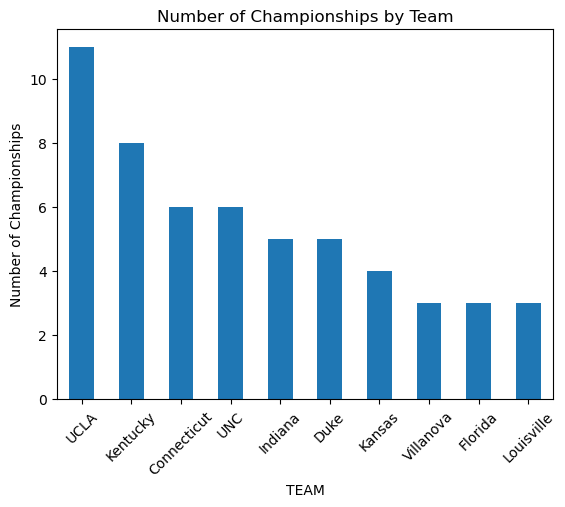

In [6]:
# Seeing 10 number of championships won by team
champs = (cbb.groupby('TEAM')['Num_of_champs']
          .max()
          .sort_values(ascending=False)
          .head(10))

champs.plot(x='TEAM', y='Num_of_champs', kind='bar')
plt.title('Number of Championships by Team')
plt.xlabel('TEAM')
plt.xticks(rotation=45)
plt.ylabel('Number of Championships')
plt.show()

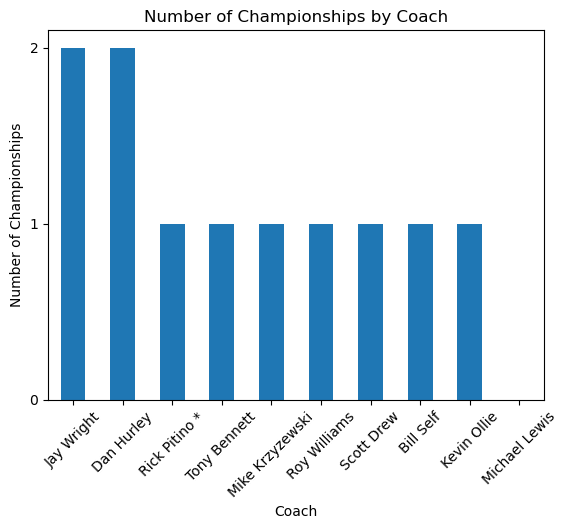

In [7]:
# Seeing the number of championships by coach
cbb['won_champ'] = (cbb['POSTSEASON'] == 'Champions').astype(int)
cbb = cbb.sort_values(['Coach', 'YEAR'])
cbb['Coach_champs'] = cbb.groupby('Coach')['won_champ'].cumsum()


coach = (cbb.groupby('Coach')['Coach_champs']
         .max()
         .sort_values(ascending=False)
         .head(10)
         )


ax = coach.plot(x='Coach', y='Num_of_champs', kind='bar')
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Number of Championships by Coach')
plt.xlabel('Coach')
plt.xticks(rotation=45)
plt.ylabel('Number of Championships')
plt.show()

In [14]:
from sklearn.model_selection import StratifiedKFold
# Doing the same for Last_yr_performance since it's based on the target variable (POSTSEASON)
round_map_feat = {
    "69": 0,
    "R64": 1,
    "R32": 2,
    "S16": 3,
    "E8": 4,
    "F4": 5,
    "2ND": 6,
    "Champions": 7
}

cbb["Last_yr_performance"] = (
    cbb["Last_yr_performance"]
    .map(round_map_feat)
    .fillna(1)
    .astype(int)
)

# Features
features = [
    'ADJOE','ADJDE','BARTHAG','EFG_O','EFG_D','TOR','TORD','ORB',
    'FTR','FTRD','2P_O','2P_D','3P_O','3P_D','ADJ_T',
    'Num_of_champs','Last_yr_performance','Coach_champs'
]

# Features and target variable defined
X = cbb[features].copy()
y = cbb['POSTSEASON'].copy()

# Mapping the string to numeric values for the target variable (POSTSEASON)
round_map = {
    "R64":1,
    "R32":2,
    "S16":3,
    "E8":4,
    "F4":5,
    "2ND":6,
    "Champions":7
}


y_encode = y.map(round_map)

y_encode = y_encode - 1

# Masking the target parameter so the cross validation doesn't crash
mask = y_encode.notna()
X = X.loc[mask]
y_encode = y_encode.loc[mask].astype(int)

num_class = y_encode.nunique()

print(sorted(y_encode.unique()))
print(y_encode.min(), y_encode.max())



[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
0 6


In [15]:
# Creating a function that will build a boosting model based on the number of trees you want
def get_model(num_trees):
    return xgb.XGBClassifier(
        objective='multi:softprob',
        n_estimators=num_trees,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.7,
        colsample_bytree=0.7,
        num_class=num_class,
        eval_metric='mlogloss',
        random_state=200
    )

# Things I will need to create the cross validation evaluator function 
scoring = { "accuracy": "accuracy", 
           "precision": "precision_weighted", 
           "recall": "recall_weighted", 
           "f1": "f1_weighted" }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=200)

# Creating a function that cross-validates the model, and then returns some evaluation metrics 
def evaluate_model_classifier(model, X, y, cv):
    scores = cross_validate( model, X, y, cv=cv, scoring=scoring, return_train_score=False) 
    
    # Predictions for confusion matrix 
    y_pred = cross_val_predict(model, X, y, cv=cv) 
    return { "Accuracy": scores["test_accuracy"].mean(), 
            "Precision": scores["test_precision"].mean(), 
            "Recall": scores["test_recall"].mean(), 
            "F1": scores["test_f1"].mean(), 
            "Confusion Matrix": confusion_matrix(y, y_pred), 
            "Classification Report": classification_report(y, y_pred) }

boost_out = []

for num_trees in range(1, 300, 50):
    model = get_model(num_trees)
    res = evaluate_model_classifier(model, X, y_encode, cv)
    boost_out.append(res["Accuracy"])


c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

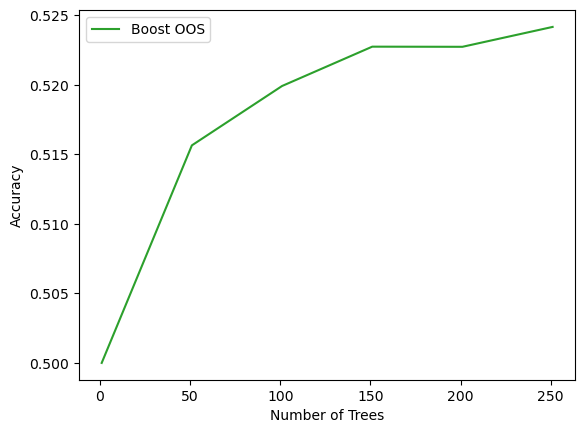

In [16]:
plt.plot(range(1,300,50), boost_out, c='tab:green', label='Boost OOS')
plt.legend()
plt.ylabel("Accuracy")
plt.xlabel("Number of Trees")
plt.show()

Accuracy:  0.524822695035461
              precision    recall  f1-score   support

           0       0.63      0.94      0.76        71
           1       0.24      0.11      0.15        35
           2       0.15      0.11      0.13        18
           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         2
           6       0.33      0.50      0.40         2

    accuracy                           0.52       141
   macro avg       0.19      0.24      0.21       141
weighted avg       0.40      0.52      0.44       141



c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

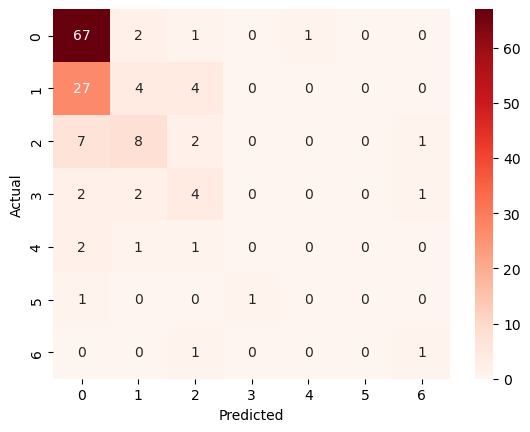

In [ ]:
# Fitting our model with the best number of trees
final = xgb.XGBClassifier(
        objective='multi:softmax',
        n_estimators=400,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.7,
        colsample_bytree=0.7,
        num_class=num_class,
        eval_metric='mlogloss',
        random_state=200
    )

RNG = 200
x_train, x_test, y_train, y_test = train_test_split(
    X, y_encode, test_size=0.2, random_state = RNG, stratify=y_encode
)
final.fit(x_train, y_train)
y_pred = final.predict(x_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [18]:
import joblib

joblib.dump(final, "NCAABballPredictor.pk1")

['NCAABballPredictor.pk1']

In [13]:
# Seeing if a neural network is better
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

num_classes = len(np.unique(y_train))

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


print(classification_report(y_test, y_pred_classes))


Epoch 1/50


c:\Users\Camro\miniconda3\envs\cp1\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3622 - loss: 1.7626 - val_accuracy: 0.5044 - val_loss: 1.5043
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5289 - loss: 1.3505 - val_accuracy: 0.5221 - val_loss: 1.3407
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5467 - loss: 1.2184 - val_accuracy: 0.5044 - val_loss: 1.2608
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5689 - loss: 1.1509 - val_accuracy: 0.5133 - val_loss: 1.2539
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5844 - loss: 1.1049 - val_accuracy: 0.4956 - val_loss: 1.2470
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6133 - loss: 1.0704 - val_accuracy: 0.4690 - val_loss: 1.2336
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6178 - loss: 1.0463 - val_accuracy: 0.4867 - val_loss: 1.2529
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6222 - loss: 1.0205 - val_accuracy: 0.4690 - val_loss: 1.2399
E